---
tags: [integration, optimization, variational]
---

# CUDA-Q Support

This page introduces Qamomile's [CUDA-Q](https://nvidia.github.io/cuda-quantum/latest/) backend through the same concrete optimization problem used in the [QURI Parts Support](quri_parts_support.ipynb) page.
We represent a small MaxCut instance as an Ising problem with `BinaryModel.from_ising` and write the QAOA ansatz directly as a `@qkernel`.
Then we run that kernel through `CudaqTranspiler` / `CudaqExecutor`.
`CudaqExecutor` uses the active CUDA-Q target; by default, CUDA-Q's local CPU simulator is enough for the examples below.
Along the way, we will inspect the generated CUDA-Q source and compare Qamomile's `STATIC` and `RUNNABLE` CUDA-Q execution modes.

In [1]:
# Install Qamomile with the CUDA-Q optional dependency group that matches
# your CUDA-Q installation target.
# !pip install "qamomile[cudaq-cu12]"  # CUDA 12.x, Linux
# !pip install "qamomile[cudaq-cu13]"  # CUDA 13.x, Linux or macOS ARM64

In [2]:
import os
from collections import Counter

import cudaq
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.optimize import minimize

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.cudaq import CudaqExecutor, CudaqTranspiler, ExecutionMode
from qamomile.optimization.binary_model import BinaryModel

## The MaxCut problem

We use the same small 5-node graph from the [QAOA for MaxCut tutorial](../algorithm/qaoa_maxcut.ipynb) so the focus stays on the CUDA-Q integration.
Maximizing $\sum_{(i,j) \in E}(1 - s_i s_j)/2$ is equivalent, up to a constant, to *minimizing* the antiferromagnetic Ising Hamiltonian $H_C = \sum_{(i,j) \in E} s_i s_j$.
For unweighted MaxCut, every $J_{ij} = 1$ and every $h_i = 0$, so we pass these coefficients directly to `BinaryModel.from_ising`.
The model object is used as a problem container that gives us `quad` / `linear` dictionaries for the QAOA kernel and a helper for decoding measurements back into spin values $(+1 / -1)$.

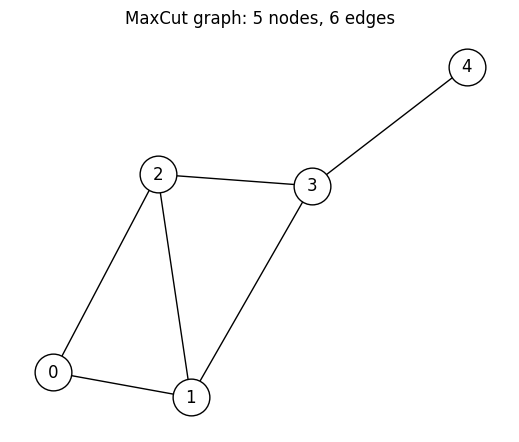

In [3]:
G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()

ising_quad: dict[tuple[int, int], float] = {
    tuple(sorted((i, j))): 1.0 for i, j in G.edges()
}
ising_linear: dict[int, float] = {}
spin_model = BinaryModel.from_ising(linear=ising_linear, quad=ising_quad)
# The problem structure is fully determined by the graph: one quad term per edge
# and no linear terms for unweighted MaxCut. Assert so a regression in
# `BinaryModel.from_ising` is caught when this notebook runs in CI.
assert len(spin_model.quad) == G.number_of_edges()
assert len(spin_model.linear) == 0

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"MaxCut graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

## Building the QAOA ansatz with `@qkernel`

We write the QAOA ansatz directly as a small `@qkernel`.
The recipe is the same as in the [QAOA for MaxCut tutorial](../algorithm/qaoa_maxcut.ipynb): start from a uniform superposition, apply $p$ rounds of cost and mixer layers, then measure in the computational basis.

:::{tip}
Qamomile's rotation gates follow the $e^{-i\theta/2}$ convention.
Because of that, the $1/2$ factor is handled slightly differently in the cost and mixer layers.
In the mixer layer, we pass $2\beta$ to `rx`, so the $1/2$ cancels and we get the textbook $e^{-i\beta X}$.
In the cost layer, we pass $J_{ij} \cdot \gamma$ to `rzz`, so the $1/2$ remains.
This coefficient difference is absorbed into the variational parameter $\gamma$: the $\gamma$ used here is twice the textbook QAOA $\gamma$.
:::

In [4]:
@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q


@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=hi * gamma)
    return q


@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q


@qmc.qkernel
def qaoa_ansatz(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.measure(q)

`qaoa_ansatz.draw(...)` renders the Qamomile circuit diagram.
We pass concrete values for the arguments that determine the problem structure (`p`, `quad`, `linear`, `n`) so the layered shape is visible.
Meanwhile, `gammas` / `betas` remain symbolic parameters.

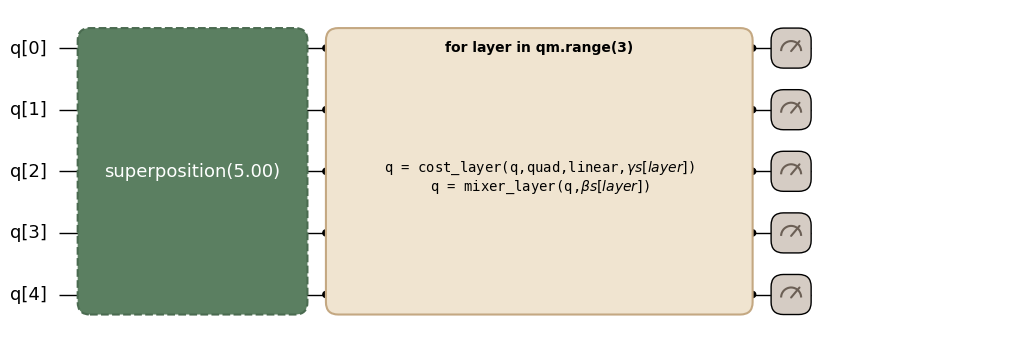

In [5]:
p = 3  # number of QAOA layers
qaoa_ansatz.draw(
    p=p,
    quad=spin_model.quad,
    linear=spin_model.linear,
    n=num_nodes,
)

## Transpile to CUDA-Q

`CudaqTranspiler` is used with `transpile()` the same way as any other backend.
We bind the arguments that determine the problem structure and keep `gammas` / `betas` as runtime parameters.

In [6]:
transpiler = CudaqTranspiler()
executor = CudaqExecutor()

executable = transpiler.transpile(
    qaoa_ansatz,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

`executable.get_first_circuit()` returns Qamomile's CUDA-Q backend artifact, `CudaqKernelArtifact`.
This is a Qamomile-side wrapper around the generated `@cudaq.kernel` function, not a type from the upstream `cudaq` Python package.
The artifact keeps an inspectable Python source string for the generated CUDA-Q kernel, and the $2p$ QAOA angles (`gammas[0..p-1]`, `betas[0..p-1]`) remain available as named runtime parameters.
We can confirm that with `type(...)`, the qubit count, and the parameter count, then inspect the generated source.
This source string is useful when you want to see exactly what Qamomile handed to CUDA-Q, including gate decompositions such as the `rzz` layer below.

In [7]:
cudaq_artifact = executable.get_first_circuit()
assert cudaq_artifact is not None  # transpile() always emits one quantum segment here
# `num_qubits` and `param_count` are fully determined by the problem setting:
# one qubit per graph node, and one runtime parameter per (gamma | beta) per layer.
# Assert them so docs tests catch a regression in the CUDA-Q emit pass.
assert cudaq_artifact.num_qubits == num_nodes
assert cudaq_artifact.param_count == 2 * p
assert cudaq_artifact.execution_mode == ExecutionMode.STATIC
assert len(executable.parameter_names) == 2 * p
print(type(cudaq_artifact).__name__)
print("execution_mode :", cudaq_artifact.execution_mode.value)
print("num_qubits     :", cudaq_artifact.num_qubits)
print("param_count    :", cudaq_artifact.param_count)
print("parameter_names:", executable.parameter_names)

assert "@cudaq.kernel" in cudaq_artifact.source
assert "x.ctrl" in cudaq_artifact.source
assert "rz(" in cudaq_artifact.source
print(cudaq_artifact.source)

CudaqKernelArtifact
execution_mode : static
num_qubits     : 5
param_count    : 6
parameter_names: ['gammas[0]', 'betas[0]', 'gammas[1]', 'betas[1]', 'gammas[2]', 'betas[2]']
@cudaq.kernel
def _qamomile_kernel(thetas: list[float]):
    q = cudaq.qvector(5)
    __b0 = False
    __b1 = False
    __b2 = False
    __b3 = False
    __b4 = False
    h(q[0])
    h(q[1])
    h(q[2])
    h(q[3])
    h(q[4])
    x.ctrl(q[0], q[1])
    rz((1.0) * (thetas[0]), q[1])
    x.ctrl(q[0], q[1])
    x.ctrl(q[0], q[2])
    rz((1.0) * (thetas[0]), q[2])
    x.ctrl(q[0], q[2])
    x.ctrl(q[1], q[2])
    rz((1.0) * (thetas[0]), q[2])
    x.ctrl(q[1], q[2])
    x.ctrl(q[1], q[3])
    rz((1.0) * (thetas[0]), q[3])
    x.ctrl(q[1], q[3])
    x.ctrl(q[2], q[3])
    rz((1.0) * (thetas[0]), q[3])
    x.ctrl(q[2], q[3])
    x.ctrl(q[3], q[4])
    rz((1.0) * (thetas[0]), q[4])
    x.ctrl(q[3], q[4])
    rx((thetas[1]) * (2.0), q[0])
    rx((thetas[1]) * (2.0), q[1])
    rx((thetas[1]) * (2.0), q[2])
    rx((thetas[1

Each runtime parameter remains unbound until execution time.
That means binding `gammas` / `betas` is treated as a parameter-value update on the CUDA-Q side rather than a Qamomile rebuild.
The problem structure, such as the Ising coefficients, qubit count, and number of layers, is fixed at compile time, leaving only the variational angles as runtime inputs.

## Sampling QAOA with `CudaqExecutor`

`executable.sample(executor, bindings=..., shots=...)` returns a `SampleJob`.
Calling `.result()` gives a `SampleResult`, which `BinaryModel.decode_from_sampleresult` decodes into a `BinarySampleSet` of spin variables $(+1 / -1)$.
This lets us count cut edges without any additional conversion.
`CudaqExecutor()` runs against the active CUDA-Q target; by default that is CUDA-Q's local CPU simulator.

In [8]:
rng = np.random.default_rng(42)
init_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)
init_gammas = list(init_params[:p])
init_betas = list(init_params[p:])
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2000
maxiter = 20 if docs_test_mode else 100

sample_result = executable.sample(
    executor,
    bindings={"gammas": init_gammas, "betas": init_betas},
    shots=sample_shots,
).result()

decoded = spin_model.decode_from_sampleresult(sample_result)
print(f"Mean energy at random init: {decoded.energy_mean():+.4f}")

Mean energy at random init: -0.6240


## Optimizing the QAOA parameters

A QAOA optimization loop reuses the same `ExecutableProgram` object across many `(gammas, betas)` vectors.
Call `transpiler.transpile()` once, then call `executable.sample()` many times.
In this example, we define the sampling and decoding work as `cost_fn()` and optimize it with SciPy's `minimize` function.
The classical optimizer updates `(gammas, betas)` while lowering the mean sampled Ising energy.
Each iteration reuses the same `ExecutableProgram` object and `CudaqExecutor`.

In [9]:
cost_history: list[float] = []


def cost_fn(params: np.ndarray) -> float:
    result = executable.sample(
        executor,
        bindings={"gammas": list(params[:p]), "betas": list(params[p:])},
        shots=sample_shots,
    ).result()
    energy = spin_model.decode_from_sampleresult(result).energy_mean()
    cost_history.append(energy)
    return energy


res = minimize(cost_fn, init_params, method="COBYLA", options={"maxiter": maxiter})

opt_gammas = list(res.x[:p])
opt_betas = list(res.x[p:])
print(f"Optimized mean energy: {res.fun:+.4f}")
print(f"Optimal gammas       : {[round(float(v), 4) for v in opt_gammas]}")
print(f"Optimal betas        : {[round(float(v), 4) for v in opt_betas]}")

Optimized mean energy: -2.6220
Optimal gammas       : [1.6054, -1.0093, 1.0498]
Optimal betas        : [-0.0567, -1.99, 1.3111]


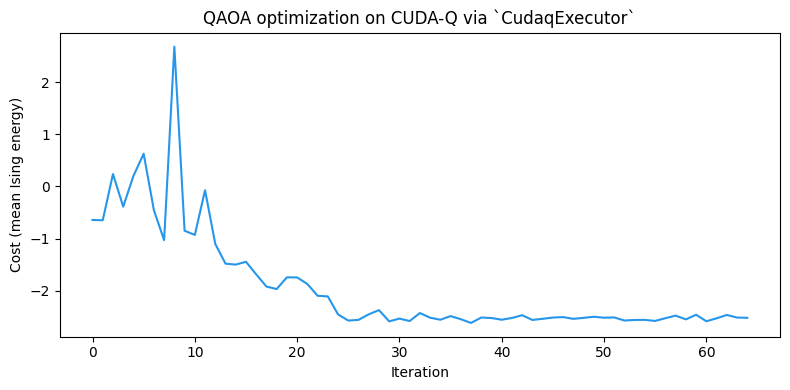

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean Ising energy)")
plt.title("QAOA optimization on CUDA-Q via `CudaqExecutor`")
plt.tight_layout()
plt.show()

Sampling is probabilistic, and different CUDA-Q targets can use different simulator implementations.
Because of that, the optimization trajectory and final sampled energy may vary slightly across runs.
The optimizer should still converge close to the ground-state energy of $H_C$ on this 5-node graph.
The optimized parameters from this run (`opt_gammas`, `opt_betas`) are reused throughout the rest of this page.

## Expectation values through `cudaq.observe`

For `STATIC` CUDA-Q artifacts, `CudaqExecutor.estimate(circuit, hamiltonian, params=...)` calls `cudaq.observe()` under the hood.
The measured QAOA ansatz above is still usable as a state-preparation circuit because Qamomile does not write terminal measurements into the generated CUDA-Q kernel for `STATIC` artifacts.
Sampling handles the final measurement separately, so the same emitted artifact can also be used by `cudaq.observe()`.
In a QAOA optimizer, you can keep the same circuit and replace `ExecutableProgram.sample()` plus decoding with `executor.estimate(circuit, hamiltonian, params=...)`.

First build a Qamomile `Hamiltonian` for $H_C = \sum_{(i,j) \in E} Z_i Z_j$.
Then call `executor.estimate` on the CUDA-Q artifact emitted by `transpile()`.

In [11]:
cost_hamiltonian = qm_o.Hamiltonian()
for (i, j), Jij in spin_model.quad.items():
    cost_hamiltonian.add_term(
        (qm_o.PauliOperator(qm_o.Pauli.Z, i), qm_o.PauliOperator(qm_o.Pauli.Z, j)),
        Jij,
    )
for i, hi in spin_model.linear.items():
    cost_hamiltonian.add_term((qm_o.PauliOperator(qm_o.Pauli.Z, i),), hi)

unbound_circuit = executable.get_first_circuit()
assert unbound_circuit is not None
assert unbound_circuit.execution_mode == ExecutionMode.STATIC
print(f"artifact type       : {type(unbound_circuit).__name__}")
print(f"artifact param_count: {unbound_circuit.param_count}")

# CUDA-Q requires the runtime parameters as a flat list in the order
# they were registered on the artifact, which is the first-use order during
# circuit emission. For QAOA that means gammas[0], betas[0], gammas[1], betas[1],
# ..., interleaved per layer, NOT all gammas followed by all betas.
# Read the order from the `ExecutableProgram` and build the flat list by lookup so
# we never have to guess the convention.
named_values = {f"gammas[{i}]": opt_gammas[i] for i in range(p)}
named_values.update({f"betas[{i}]": opt_betas[i] for i in range(p)})
flat_params = [named_values[name] for name in executable.parameter_names]
# The runtime parameter set is the 2p QAOA angles; assert this so a future
# change to how CudaqTranspiler registers parameters is caught here.
assert len(executable.parameter_names) == 2 * p
assert len(flat_params) == 2 * p
print(f"artifact parameter order: {executable.parameter_names}")

energy_via_estimate = executor.estimate(
    unbound_circuit, cost_hamiltonian, params=flat_params
)
print(f"executor.estimate: {energy_via_estimate:+.10f}")
assert np.isfinite(energy_via_estimate)

artifact type       : CudaqKernelArtifact
artifact param_count: 6
artifact parameter order: ['gammas[0]', 'betas[0]', 'gammas[1]', 'betas[1]', 'gammas[2]', 'betas[2]']
executor.estimate: -2.5469353310


`ExecutableProgram.run(...)` can also drive expectation-value kernels directly.
In the next kernel, the observable is a Qamomile runtime argument and the kernel returns `qmc.expval(...)` instead of measured bits.
This higher-level path also reaches `CudaqExecutor.estimate`, but the observable and parameter bindings are managed by Qamomile's `ExecutableProgram`.

In [12]:
@qmc.qkernel
def qaoa_expval(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
    obs: qmc.Observable,
) -> qmc.Float:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.expval(q, obs)


expval_executable = transpiler.transpile(
    qaoa_expval,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
        "obs": cost_hamiltonian,
    },
    parameters=["gammas", "betas"],
)
energy_from_run = expval_executable.run(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
).result()

print(f"ExecutableProgram.run: {energy_from_run:+.10f}")
assert np.isclose(energy_from_run, energy_via_estimate, atol=1e-10)

ExecutableProgram.run: -2.5469353310


Both paths agree to numerical precision.
They evaluate the same QAOA state against the same Ising cost Hamiltonian.
The resulting noise-free expectation value at the optimized parameters should also match the sample-mean energy printed earlier within shot noise.

## Choosing CUDA-Q targets

`CudaqExecutor()` uses the current CUDA-Q target, while `CudaqExecutor(target=...)` or `CudaqTranspiler.executor(target=...)` selects a target explicitly.
The custom executor can be used anywhere `executor` appeared above.
Changing the CUDA-Q target does not require re-transpiling the kernel.
The `ExecutableProgram` carries the emitted CUDA-Q artifact, while the executor carries the runtime target selection.
The list of simulator targets you can select is maintained in CUDA-Q's [Circuit Simulation Backends](https://nvidia.github.io/cuda-quantum/latest/using/backends/simulators.html) documentation.

As a concrete local example, we first sample the **same** optimized QAOA `ExecutableProgram` on the default target.
Then we switch to CUDA-Q's `density-matrix-cpu` target with a small depolarization noise model.

The density-matrix simulator is useful when you want CPU-based noisy simulation.
CUDA-Q provides `Depolarization1` for single-qubit operations and `Depolarization2` for two-qubit operations.
Qamomile's CUDA-Q emitter decomposes each `rzz` into `x.ctrl` / `rz` / `x.ctrl`, so the noise model below applies single-qubit depolarization to the rotation gates and two-qubit depolarization to controlled `x` gates (`num_controls=1`).

In CUDA-Q's noise model API, controlled `x` is registered as operator `"x"` with `num_controls=1`; `"x.ctrl"` is not a separate operator name.
CUDA-Q stores both the active target and the noise model globally, and calling `cudaq.set_target(...)` clears the current noise model.
For a noisy run, set the target first, set the noise model second, then use an executor that does not reapply `target=...` during the call.

On a GPU-enabled installation, the same pattern applies to GPU-backed CUDA-Q targets and noisy simulators.

In [13]:
default_result = executable.sample(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
    shots=sample_shots,
).result()
noise_probability = 0.02
noise_model = cudaq.NoiseModel()
for gate_name in ("h", "rx", "rz"):
    noise_model.add_all_qubit_channel(
        gate_name, cudaq.Depolarization1(noise_probability)
    )
noise_model.add_all_qubit_channel(
    "x",
    cudaq.Depolarization2(noise_probability),
    num_controls=1,
)

try:
    cudaq.set_target("density-matrix-cpu")
    cudaq.set_noise(noise_model)
    noisy_density_result = executable.sample(
        executor,
        bindings={"gammas": opt_gammas, "betas": opt_betas},
        shots=sample_shots,
    ).result()
finally:
    cudaq.unset_noise()
    cudaq.reset_target()

default_decoded = spin_model.decode_from_sampleresult(default_result)
noisy_density_decoded = spin_model.decode_from_sampleresult(noisy_density_result)
default_energy = default_decoded.energy_mean()
noisy_density_energy = noisy_density_decoded.energy_mean()
print(f"default target mean energy           : {default_energy:+.4f}")
print(f"density-matrix-cpu noisy mean energy: {noisy_density_energy:+.4f}")

default target mean energy           : -2.5650
density-matrix-cpu noisy mean energy: -1.0190


Because both target runs use sampling, we can compare their sampled energy distributions directly.
The vertical line in each subplot marks the sample mean energy.

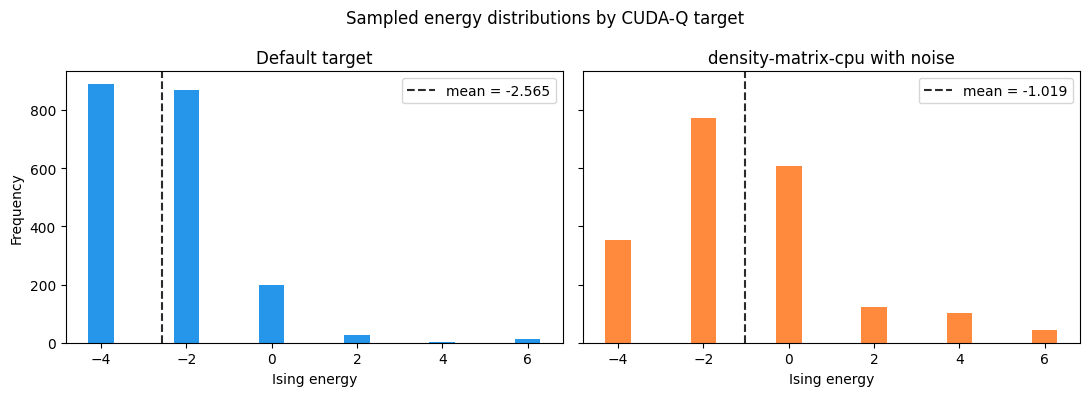

In [14]:


def energy_distribution(decoded_samples):
    counts: Counter[float] = Counter()
    for energy, occ in zip(decoded_samples.energy, decoded_samples.num_occurrences):
        counts[energy] += occ
    energies = sorted(counts.keys())
    return energies, [counts[energy] for energy in energies]


fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, decoded_samples, mean_energy, title, color in [
    (axes[0], default_decoded, default_energy, "Default target", "#2696EB"),
    (
        axes[1],
        noisy_density_decoded,
        noisy_density_energy,
        "density-matrix-cpu with noise",
        "#FF8A3D",
    ),
]:
    energies, counts = energy_distribution(decoded_samples)
    ax.bar(energies, counts, width=0.6, color=color)
    ax.axvline(
        mean_energy,
        color="#2B2B2B",
        linestyle="--",
        linewidth=1.5,
        label=f"mean = {mean_energy:+.3f}",
    )
    ax.set_xticks(energies)
    ax.set_title(title)
    ax.set_xlabel("Ising energy")
    ax.legend()

axes[0].set_ylabel("Frequency")
fig.suptitle("Sampled energy distributions by CUDA-Q target")
fig.tight_layout()
plt.show()

## Runtime control flow: `STATIC` vs. `RUNNABLE` artifacts

Most variational circuits, including the QAOA ansatz above, compile to `ExecutionMode.STATIC`.
`STATIC` artifacts have no explicit terminal measurement in the generated CUDA-Q source, so they are compatible with CUDA-Q's `sample` and `observe` APIs.

If a Qamomile kernel contains runtime measurement-dependent control flow, such as `if bit:` or `while bit:`, the CUDA-Q backend emits an `ExecutionMode.RUNNABLE` artifact instead.
`RUNNABLE` artifacts use explicit `mz(...)` measurements in the generated source and execute through `cudaq.run()`.
The following tiny feed-forward circuit demonstrates that path.

In [15]:
@qmc.qkernel
def measurement_feed_forward() -> qmc.Bit:
    q0 = qmc.qubit("q0")
    q1 = qmc.qubit("q1")
    q0 = qmc.x(q0)
    bit = qmc.measure(q0)
    if bit:
        q1 = qmc.x(q1)
    return qmc.measure(q1)


runnable_executable = transpiler.transpile(measurement_feed_forward)
runnable_circuit = runnable_executable.get_first_circuit()
assert runnable_circuit is not None
assert runnable_circuit.execution_mode == ExecutionMode.RUNNABLE
assert "mz(" in runnable_circuit.source
assert "if " in runnable_circuit.source

print("execution_mode:", runnable_circuit.execution_mode.value)
print(runnable_circuit.source)

execution_mode: runnable
@cudaq.kernel
def _qamomile_kernel() -> list[bool]:
    q = cudaq.qvector(2)
    __b0 = False
    __b1 = False
    x(q[0])
    __b0 = mz(q[0])
    if __b0:
        x(q[1])
    __b1 = mz(q[1])
    return [__b0, __b1]



`ExecutableProgram.sample(...)` still works for `RUNNABLE` artifacts, but the executor dispatches to `cudaq.run()` rather than `cudaq.sample()`.
The example above is deterministic: the first measurement is always `1`, so the branch flips `q1` and the returned bit is always `1`.

In [16]:
runnable_shots = 128
runnable_sample = runnable_executable.sample(executor, shots=runnable_shots).result()
print(runnable_sample.results)
assert sum(count for _, count in runnable_sample.results) == runnable_shots
assert all(value == 1 for value, _ in runnable_sample.results)

[(1, 128)]


The trade-off is that `RUNNABLE` artifacts are not compatible with CUDA-Q's `observe` API.
Qamomile surfaces that distinction as a `TypeError` when `estimate()` is called on a `RUNNABLE` artifact.

In [17]:
try:
    executor.estimate(runnable_circuit, qm_o.Z(0))
except TypeError as exc:
    print(type(exc).__name__, exc)
else:
    raise AssertionError("RUNNABLE CUDA-Q circuits must reject observe()")

TypeError cudaq.observe() is not supported for runtime control flow circuits. Use sample() or run() instead.


## Summary

- `CudaqTranspiler().transpile(kernel, bindings=..., parameters=[...])` converts the kernel to a CUDA-Q artifact with inspectable Python source.
- `CudaqExecutor` supports both `ExecutableProgram.sample()` for QAOA-style sampling and `executor.estimate(...)` for noise-free expectation values through CUDA-Q's `observe` API.
- QAOA-style `STATIC` artifacts can be reused across many runtime parameter vectors without re-transpiling the kernel.
- Runtime measurement-dependent control flow is emitted as `ExecutionMode.RUNNABLE` and executed through `cudaq.run()`.
- CUDA-Q targets can be selected through `CudaqExecutor(target=...)` or `CudaqTranspiler.executor(target=...)`; the `ExecutableProgram` does not need to be transpiled again.

### See also

- [QURI Parts Support](quri_parts_support.ipynb) covers the same MaxCut QAOA workflow on the QURI Parts backend.